In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

import keras
from keras.models import Sequential
from keras.layers import Reshape
from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error

from tensorflow.keras.layers import BatchNormalization
import cv2
from tensorflow.keras.optimizers import Adam , Adadelta

warnings.filterwarnings('ignore')

In [2]:
"""from keras.layers import LayerNormalization"""


'from keras.layers import LayerNormalization'

In [3]:
import pandas as pd

test = pd.read_csv("../input/mit-bih/MIt-BIH Datasets/MIt-BIH Datasets/test.csv" , header = None)
#display_test = pd.read_csv("../input/test-data-new/test.csv" , header = None)

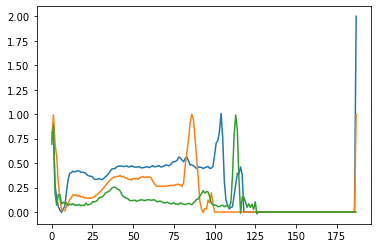

In [4]:

for i in range(3): plt.plot(test.iloc[i])
plt.show()

In [5]:

test.rename(columns={187:"Class"}, inplace=True)

#display_test.rename(columns={187:"Class"}, inplace=True)

In [6]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
             
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18: 'Fusion of paced and normal beat'

               }

In [7]:

test['label'] = test.iloc[:, -1].map(mapping)

#display_test['label'] = display_test.iloc[:, -1].map(mapping)



In [8]:

X_test=test.iloc[:,:186].values

#X_display = display_test.iloc[: , :186].values

In [9]:

X_test = X_test.reshape(len(X_test), X_test.shape[1],1)

#X_display = X_display.reshape(len(X_display), X_display.shape[1],1)

In [10]:
target_test=test["Class"]
#target_display = display_test["Class"]

In [11]:

y_test= np.array(target_test).reshape(-1,1)

#y_display = np.array(target_display).reshape(-1,1)

In [12]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoder_df2 = pd.DataFrame(enc.fit_transform(y_test).toarray())
#encoder_df4 = pd.DataFrame(enc.fit_transform(y_display).toarray())




In [13]:
y_test = np.array(encoder_df2)

#y_display = np.array(encoder_df4)

In [14]:
import tensorflow


X_test = tensorflow.convert_to_tensor(X_test, dtype=tensorflow.float32)
y_test = tensorflow.convert_to_tensor(y_test, dtype=tensorflow.float32)



#X_display = tensorflow.convert_to_tensor(X_display, dtype=tensorflow.float32)
#y_display = tensorflow.convert_to_tensor(y_display, dtype=tensorflow.float32)


2022-05-20 19:32:31.748593: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-20 19:32:31.889840: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-20 19:32:31.890656: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-20 19:32:31.893456: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [15]:
from tensorflow import keras
model = keras.models.load_model('../input/mit-bih/simple_RNN_model_.h5')

In [16]:
y_pred = model.predict(X_test, batch_size=1000)

2022-05-20 19:32:35.028970: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


In [17]:
y_pred=np.argmax(y_pred, axis=1)

In [18]:
yyy_test = np.argmax(y_test , axis = 1)

In [19]:
print("Model Accuracy is : " , accuracy_score(yyy_test, y_pred) )

Model Accuracy is :  0.9076845806127574


In [20]:
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=128)
print("test loss, test acc:", results)


Evaluate on test data
234/234 [==============================] - 11s 47ms/step - loss: 0.2861 - accuracy: 0.9077
test loss, test acc: [0.2860836088657379, 0.9076845645904541]


In [21]:
# converting hsitory to dataframe
"""
pd.DataFrame(history.history)

pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
"""

"\npd.DataFrame(history.history)\n\npd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()\nplt.title('Training Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('accuracy')\n\npd.DataFrame(history.history)[['loss', 'val_loss']].plot()\nplt.title('Model Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\n"

In [22]:
print(classification_report(yyy_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     22457
           1       0.90      0.98      0.94      1274
           2       0.94      0.96      0.95      1986
           3       0.49      0.78      0.60       618
           4       0.14      0.50      0.22        22
           5       0.26      0.68      0.38        22
           6       0.50      0.87      0.63       982
           7       0.48      0.82      0.60       169
           8       0.14      0.65      0.23        54
           9       0.56      0.85      0.68        26
          10       0.94      0.97      0.96      1932
          11       0.49      0.81      0.61       320
          12       0.00      0.00      0.00         3

    accuracy                           0.91     29865
   macro avg       0.53      0.75      0.60     29865
weighted avg       0.94      0.91      0.92     29865



In [23]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


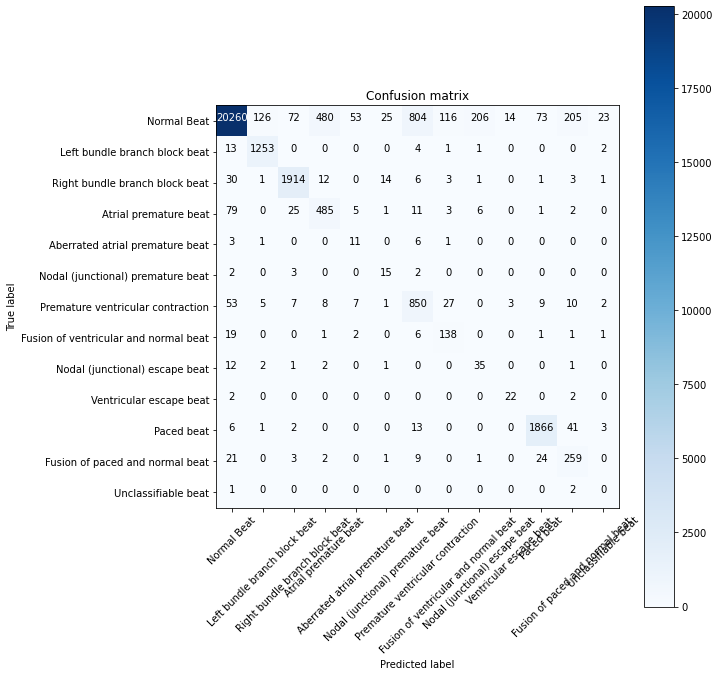

In [24]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(yyy_test, y_pred)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=[
                                           
                'Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
                'Atrial premature beat',
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
               
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
               
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'

],
                      title='Confusion matrix')
plt.show()

In [25]:
from sklearn import metrics
import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 


In [26]:


fpr, tpr, thresholds = metrics.roc_curve(yyy_test, y_pred, pos_label=2)

In [27]:
print(fpr)

[0.         0.00111195 0.01987159 0.09067757 0.09207647 0.10100793
 0.11126654 0.17242369 0.17400194 0.17679974 0.21187991 0.21593314
 0.26571972 1.        ]


In [28]:
print(tpr)

[0.00000000e+00 5.03524673e-04 2.01409869e-03 2.51762336e-03
 2.51762336e-03 3.02114804e-03 4.53172205e-03 7.55287009e-03
 1.46022155e-02 1.46022155e-02 2.06445116e-02 9.84390735e-01
 9.84894260e-01 1.00000000e+00]


In [29]:
print(thresholds)

[13 12 11 10  9  8  7  6  5  4  3  2  1  0]


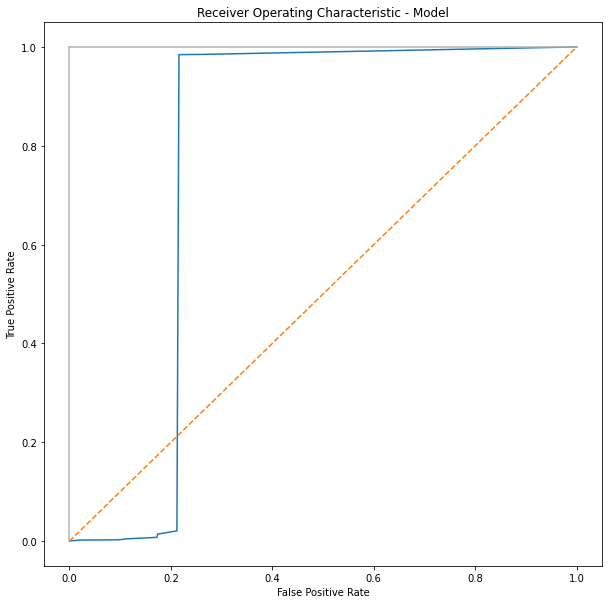

In [30]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Model')
plt.plot(fpr, tpr)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [31]:

auc = metrics.auc(fpr, tpr)
print("Auc is : ")
print(auc )


Auc is : 
0.7810905850621122
